
## **Task 1 – Context**

### **1. Scenario**

As a data scientist collaborating with a thoracic surgery center, I propose a machine learning solution to support clinical decision-making for lung cancer patients undergoing major surgery. Based on a retrospective dataset of 470 patients treated between 2007 and 2011 at the Wroclaw Thoracic Surgery Centre, I aim to develop a classification model that predicts a patient's **likelihood of surviving more than one year after lung surgery**.

The goal is to use historical patient data—including clinical, demographic, and operative features—to identify high-risk patients preoperatively. This predictive tool would be integrated into the hospital’s decision support system, providing clinicians with an additional layer of insight to help them:

* Tailor treatment plans
* Consider alternative therapies or closer postoperative monitoring for high-risk patients
* Allocate resources more efficiently



### **2. Value of Solving the Problem**

The predictive model could provide substantial **clinical and operational value**, such as:

* **Improved Patient Outcomes:** Early identification of high-risk patients enables more proactive care and improved survival chances through preventive measures.
* **Optimized Use of Hospital Resources:** By knowing which patients are at greater risk, hospitals can plan for more intensive postoperative support (e.g., ICU beds, follow-ups).
* **Cost Reduction:** Preventing complications or readmissions for high-risk patients can lead to significant healthcare cost savings.
* **Enhanced Decision-Making:** Surgeons and oncologists can use the model to better assess surgical risk and patient suitability, potentially reducing unnecessary surgeries for extremely high-risk patients.

In a broader context, this kind of predictive analytics could also be extended to national cancer registries or public health decision-making, supporting evidence-based policy on surgical interventions.



### **3. Quality Criteria**

To assess the performance of the predictive models, I will use the following two quality criteria:

1. **Balanced Accuracy**

   * **Why?** In medical datasets, class imbalance is common. Here, if far more patients survive than die within one year, a naïve model might achieve high standard accuracy by mostly predicting survival. Balanced Accuracy accounts for this imbalance by averaging recall for each class.
   * **Goal:** Ensure that the model performs well for both classes (death and survival), not just the majority.


2. **F1 Score (Harmonic Mean of Precision and Recall)**

* **Why?** F1 Score balances both **precision** (how many predicted positives are actually positive) and **recall** (how many actual positives are captured by the model). It's particularly useful when dealing with **imbalanced datasets**, where accuracy can be misleading.

* **Goal:** Select a model that not only identifies most of the true positive cases (high recall), but also minimizes false positives (high precision), ensuring **reliable clinical decisions** when predicting post-operative mortality risk.


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.io import arff
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV, cross_validate

from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, accuracy_score, balanced_accuracy_score, f1_score
from sklearn.inspection import permutation_importance
from sklearn.neighbors import KNeighborsClassifier



from sklearn.base import BaseEstimator, TransformerMixin


from imblearn.pipeline import Pipeline as ImbPipeline  # Note: imbalanced-learn pipeline!

### **Task 2 – The Data**
Load and present the dataset

The dataset can be downloaded at: https://archive.ics.uci.edu/static/public/277/thoracic+surgery+data.zip

It was provided by UC irvine machine learning repository: https://archive.ics.uci.edu/dataset/277/thoracic+surgery+data

In [2]:
# Load the .arff file
data, meta = arff.loadarff('ThoraricSurgery.arff')

# Convert to a DataFrame
raw_data = pd.DataFrame(data)

# If some columns are byte strings, convert them to normal strings
for col in raw_data.select_dtypes([object]):
    raw_data[col] = raw_data[col].str.decode('utf-8')

print(raw_data.head())


    DGN  PRE4  PRE5  PRE6 PRE7 PRE8 PRE9 PRE10 PRE11 PRE14 PRE17 PRE19 PRE25  \
0  DGN2  2.88  2.16  PRZ1    F    F    F     T     T  OC14     F     F     F   
1  DGN3  3.40  1.88  PRZ0    F    F    F     F     F  OC12     F     F     F   
2  DGN3  2.76  2.08  PRZ1    F    F    F     T     F  OC11     F     F     F   
3  DGN3  3.68  3.04  PRZ0    F    F    F     F     F  OC11     F     F     F   
4  DGN3  2.44  0.96  PRZ2    F    T    F     T     T  OC11     F     F     F   

  PRE30 PRE32   AGE Risk1Yr  
0     T     F  60.0       F  
1     T     F  51.0       F  
2     T     F  59.0       F  
3     F     F  54.0       F  
4     T     F  73.0       T  


In [3]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DGN      470 non-null    object 
 1   PRE4     470 non-null    float64
 2   PRE5     470 non-null    float64
 3   PRE6     470 non-null    object 
 4   PRE7     470 non-null    object 
 5   PRE8     470 non-null    object 
 6   PRE9     470 non-null    object 
 7   PRE10    470 non-null    object 
 8   PRE11    470 non-null    object 
 9   PRE14    470 non-null    object 
 10  PRE17    470 non-null    object 
 11  PRE19    470 non-null    object 
 12  PRE25    470 non-null    object 
 13  PRE30    470 non-null    object 
 14  PRE32    470 non-null    object 
 15  AGE      470 non-null    float64
 16  Risk1Yr  470 non-null    object 
dtypes: float64(3), object(14)
memory usage: 62.6+ KB


In [4]:
raw_data.shape

(470, 17)

### **Explaination of the dataset**


### Variables Table

| Variable Name | Role     | Type        | Demographic | Description                                                                                     | Units | Missing Values |
|---------------|----------|-------------|-------------|-------------------------------------------------------------------------------------------------|--------|----------------|
| DGN           | Feature  | Categorical |             | Diagnosis - specific combination of ICD-10 codes for primary and secondary tumors               |        | No             |
| PRE4          | Feature  | Continuous  |             | Forced vital capacity - FVC (numeric)                                                           |        | No             |
| PRE5          | Feature  | Continuous  |             | Volume exhaled at the end of the first second of forced expiration - FEV1 (numeric)             |        | No             |
| PRE6          | Feature  | Categorical |             | Performance status - Zubrod scale (PRZ2, PRZ1, PRZ0)                                            |        | No             |
| PRE7          | Feature  | Binary      |             | Pain before surgery (T, F)                                                                      |        | No             |
| PRE8          | Feature  | Binary      |             | Haemoptysis before surgery (T, F)                                                               |        | No             |
| PRE9          | Feature  | Binary      |             | Dyspnoea before surgery (T, F)                                                                  |        | No             |
| PRE10         | Feature  | Binary      |             | Cough before surgery (T, F)                                                                     |        | No             |
| PRE11         | Feature  | Binary      |             | Weakness before surgery (T, F)                                                                  |        | No             |
| PRE14         | Feature  | Categorical |             | T in clinical TNM - size of original tumour (OC11-smallest to OC14-largest)                     |        | No             |
| PRE17         | Feature  | Binary      |             | Type 2 Diabetes Mellitus (T, F)                                                                 |        | No             |
| PRE19         | Feature  | Binary      |             | Myocardial Infarction up to 6 months before surgery (T, F)                                      |        | No             |
| PRE25         | Feature  | Binary      |             | Peripheral Arterial Diseases (T, F)                                                             |        | No             |
| PRE30         | Feature  | Binary      |             | Smoking (T, F)                                                                                   |        | No             |
| PRE32         | Feature  | Binary      |             | Asthma (T, F)                                                                                    |        | No             |
| AGE           | Feature  | Integer     | Age         | Age at surgery (numeric)                                                                        |        | No             |
| Risk1Yr       | Target   | Binary      |             | 1-year survival period - (T)rue if died within one year post-surgery (T, F)                     |        | No             |


### **Why the Dataset is Suitable for the Project**

The goal of the project is to develop a **predictive model to identify lung cancer patients at risk of dying within one year after surgery**. The dataset in use is highly appropriate for this objective for the following reasons:


#### **1. Real-World Clinical Relevance**

The dataset was collected from **actual lung cancer patients** treated between 2007 and 2011 at a thoracic surgery center. It contains detailed **preoperative information** such as symptoms, comorbidities, respiratory function, and demographics—all of which are relevant to patient survival. This aligns perfectly with the clinical decision-making scenario proposed in the project.


#### **2. Clearly Defined Classification Target**

The target variable, **`Risk1Yr`**, explicitly states whether a patient died within one year after surgery (`T`) or survived (`F`). This aligns directly with the **binary classification problem** defined in Task 1 and allows the application of well-established machine learning techniques for classification.


#### **3. Balanced Size for Prototyping**

With **470 instances and 16 features**, the dataset is small enough to allow **quick prototyping and experimentation**, yet large enough to train and validate models with meaningful results using techniques like **cross-validation** or **bootstrapping**.


#### **4. High Impact Use Case**

Predicting post-operative survival is a **high-stakes problem in healthcare**, and the dataset addresses this head-on. If a model trained on this data is successful, it could:

* Save lives through earlier interventions
* Help hospitals optimize patient management and resource allocation
* Contribute to national registries and clinical research


#### **5. Clean and Complete Data**

The dataset has **no missing values**, which simplifies preprocessing and reduces the risk of bias or information loss due to imputation. This enhances the reliability of the models trained on it.


### **Task 3**
Initial Data Analysis

### 1. Dataset Dimensions

- **Number of Instances (Patients):** 470  
- **Number of Features (excluding target):** 16  
- **Target Variable:** `Risk1Yr` (Binary: T = death within 1 year, F = survival)


### 2. Class Distribution (`Risk1Yr`)

In [5]:
raw_data['Risk1Yr'].value_counts(normalize=True)

Risk1Yr
F    0.851064
T    0.148936
Name: proportion, dtype: float64

### **Comment**
Significant Class imbalance

In [6]:
### Summary Statistics
raw_data.describe()


,PRE4,PRE5,AGE
count,470.000000,470.000000,470.000000
mean,3.281638,4.568702,62.534043
std,0.871395,11.767857,8.706902
min,1.440000,0.960000,21.000000
25%,2.600000,1.960000,57.000000
50%,3.160000,2.400000,62.000000
75%,3.807500,3.080000,69.000000
max,6.300000,86.300000,87.000000


### **Comment**
- Age shows a wide range, from young adults to elderly patients.
- PRE5 which stands for (Volume that has been exhaled at the end of the first second of forced expiration) seems not to be well distributed(outliers could be a possibility)

### 4. Distribution of Categorical and Binary Variables

In [7]:
"""DGN: Diagnosis - specific combination of ICD-10 codes for primary and secondary as well multiple tumours if any.
(DGN3,DGN2,DGN4,DGN6,DGN5,DGN8,DGN1)"""
raw_data['DGN'].value_counts()


DGN
DGN3    349
DGN2     52
DGN4     47
DGN5     15
DGN6      4
DGN8      2
DGN1      1
Name: count, dtype: int64

Top 3 Diagnoses (DGN):

DGN3: 349 patients

DGN2: 52 patients

DGN4: 47 patients

In [8]:
"""PRE6: Performance status - Zubrod scale (PRZ2,PRZ1,PRZ0)"""
raw_data['PRE6'].value_counts()


PRE6
PRZ1    313
PRZ0    130
PRZ2     27
Name: count, dtype: int64

In [9]:
""" PRE7: Pain before surgery (T,F)"""
raw_data['PRE7'].value_counts(normalize=True)


PRE7
F    0.934043
T    0.065957
Name: proportion, dtype: float64

In [10]:
"""Smoking (PRE30):"""
raw_data['PRE30'].value_counts(normalize=True)

PRE30
T    0.821277
F    0.178723
Name: proportion, dtype: float64

### **Interpretation:**

A large majority of patients had performance status between (PRZ0 and PRZ1), and most were smokers.

### **Task 4 – EDA and Preprocessing**


In [11]:
"""Binary Variable Encoding"""
Binary_Variables = ['PRE7', 'PRE8','PRE9','PRE10','PRE11','PRE17','PRE19','PRE25','PRE30','PRE32','Risk1Yr']
raw_data[Binary_Variables] = raw_data[Binary_Variables].apply(lambda col: col.map({'T': 1, 'F': 0}))

In [12]:
raw_data

,DGN,PRE4,PRE5,PRE6,PRE7,PRE8,PRE9,PRE10,PRE11,PRE14,PRE17,PRE19,PRE25,PRE30,PRE32,AGE,Risk1Yr
0,DGN2,2.88,2.16,PRZ1,0,0,0,1,1,OC14,0,0,0,1,0,60.0,0
1,DGN3,3.40,1.88,PRZ0,0,0,0,0,0,OC12,0,0,0,1,0,51.0,0
2,DGN3,2.76,2.08,PRZ1,0,0,0,1,0,OC11,0,0,0,1,0,59.0,0
3,DGN3,3.68,3.04,PRZ0,0,0,0,0,0,OC11,0,0,0,0,0,54.0,0
4,DGN3,2.44,0.96,PRZ2,0,1,0,1,1,OC11,0,0,0,1,0,73.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,DGN2,3.88,2.12,PRZ1,0,0,0,1,0,OC13,0,0,0,1,0,63.0,0
466,DGN3,3.76,3.12,PRZ0,0,0,0,0,0,OC11,0,0,0,1,0,61.0,0
467,DGN3,3.04,2.08,PRZ1,0,0,0,1,0,OC13,0,0,0,0,0,52.0,0
468,DGN3,1.96,1.68,PRZ1,0,0,0,1,1,OC12,0,0,0,1,0,79.0,0


In [13]:
"""Categorical Variables Encoding """
rdata = pd.get_dummies(raw_data, columns=['DGN', 'PRE6', 'PRE14'], drop_first=True)


In [14]:
rdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PRE4        470 non-null    float64
 1   PRE5        470 non-null    float64
 2   PRE7        470 non-null    int64  
 3   PRE8        470 non-null    int64  
 4   PRE9        470 non-null    int64  
 5   PRE10       470 non-null    int64  
 6   PRE11       470 non-null    int64  
 7   PRE17       470 non-null    int64  
 8   PRE19       470 non-null    int64  
 9   PRE25       470 non-null    int64  
 10  PRE30       470 non-null    int64  
 11  PRE32       470 non-null    int64  
 12  AGE         470 non-null    float64
 13  Risk1Yr     470 non-null    int64  
 14  DGN_DGN2    470 non-null    bool   
 15  DGN_DGN3    470 non-null    bool   
 16  DGN_DGN4    470 non-null    bool   
 17  DGN_DGN5    470 non-null    bool   
 18  DGN_DGN6    470 non-null    bool   
 19  DGN_DGN8    470 non-null    b

In [15]:
rdata.head(5)

,PRE4,PRE5,PRE7,PRE8,PRE9,PRE10,PRE11,PRE17,PRE19,PRE25,...,DGN_DGN3,DGN_DGN4,DGN_DGN5,DGN_DGN6,DGN_DGN8,PRE6_PRZ1,PRE6_PRZ2,PRE14_OC12,PRE14_OC13,PRE14_OC14
0,2.88,2.16,0,0,0,1,1,0,0,0,...,False,False,False,False,False,True,False,False,False,True
1,3.40,1.88,0,0,0,0,0,0,0,0,...,True,False,False,False,False,False,False,True,False,False
2,2.76,2.08,0,0,0,1,0,0,0,0,...,True,False,False,False,False,True,False,False,False,False
3,3.68,3.04,0,0,0,0,0,0,0,0,...,True,False,False,False,False,False,False,False,False,False
4,2.44,0.96,0,1,0,1,1,0,0,0,...,True,False,False,False,False,False,True,False,False,False


In [16]:
# Convert all boolean values (True/False) to integers (1/0)
df1 = rdata.astype({col: int for col in rdata.select_dtypes(include='bool').columns})


In [17]:
df1

,PRE4,PRE5,PRE7,PRE8,PRE9,PRE10,PRE11,PRE17,PRE19,PRE25,...,DGN_DGN3,DGN_DGN4,DGN_DGN5,DGN_DGN6,DGN_DGN8,PRE6_PRZ1,PRE6_PRZ2,PRE14_OC12,PRE14_OC13,PRE14_OC14
0,2.88,2.16,0,0,0,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,3.40,1.88,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
2,2.76,2.08,0,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
3,3.68,3.04,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,2.44,0.96,0,1,0,1,1,0,0,0,...,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,3.88,2.12,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
466,3.76,3.12,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
467,3.04,2.08,0,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,1,0
468,1.96,1.68,0,0,0,1,1,0,0,0,...,1,0,0,0,0,1,0,1,0,0


In [18]:
df1.describe()


,PRE4,PRE5,PRE7,PRE8,PRE9,PRE10,PRE11,PRE17,PRE19,PRE25,...,DGN_DGN3,DGN_DGN4,DGN_DGN5,DGN_DGN6,DGN_DGN8,PRE6_PRZ1,PRE6_PRZ2,PRE14_OC12,PRE14_OC13,PRE14_OC14
count,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,...,470.000000,470.00000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000
mean,3.281638,4.568702,0.065957,0.144681,0.065957,0.687234,0.165957,0.074468,0.004255,0.017021,...,0.742553,0.10000,0.031915,0.008511,0.004255,0.665957,0.057447,0.546809,0.040426,0.036170
std,0.871395,11.767857,0.248472,0.352154,0.248472,0.464114,0.372439,0.262811,0.065163,0.129488,...,0.437693,0.30032,0.175961,0.091958,0.065163,0.472157,0.232942,0.498335,0.197165,0.186912
min,1.440000,0.960000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.600000,1.960000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.160000,2.400000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,3.807500,3.080000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,6.300000,86.300000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### **Task 5 – First Impressions**

In [19]:
df = df1.copy()
# Split data
X = df.drop('Risk1Yr', axis=1)
y = df['Risk1Yr']

In [20]:


# Train-Test Split
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=1)

# --------------------------------------------------
# Define Baseline (B) - No learning, predicts most frequent class
# --------------------------------------------------
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

baseline_results = {
    'Model': 'Baseline (B)',
    'Train Balanced Accuracy': balanced_accuracy_score(y_train, baseline.predict(X_train)),
    'Test Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_baseline),
    'Train F1 Score': f1_score(y_train, baseline.predict(X_train)),
    'Test F1 Score': f1_score(y_test, y_pred_baseline)
}
baseline_results

{'Model': 'Baseline (B)',
 'Train Balanced Accuracy': np.float64(0.5),
 'Test Balanced Accuracy': np.float64(0.5),
 'Train F1 Score': 0.0,
 'Test F1 Score': 0.0}

In [21]:

# --------------------------------------------------
# Define A1 – Support Vector Classifier (with Scaling)
# --------------------------------------------------
pipe_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC())
])
pipe_svc.fit(X_train, y_train)

y_pred_svc = pipe_svc.predict(X_test)

svc_results = {
    'Model': 'Support Vector Classifier (A1)',
    'Train Balanced Accuracy': balanced_accuracy_score(y_train, pipe_svc.predict(X_train)),
    'Test Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_svc),
    'Train F1 Score': f1_score(y_train, pipe_svc.predict(X_train)),
    'Test F1 Score': f1_score(y_test, y_pred_svc)
}
svc_results

{'Model': 'Support Vector Classifier (A1)',
 'Train Balanced Accuracy': np.float64(0.5877232142857143),
 'Test Balanced Accuracy': np.float64(0.5),
 'Train F1 Score': 0.29850746268656714,
 'Test F1 Score': 0.0}

In [22]:

# --------------------------------------------------
# Define A2 – Decision Tree Classifier (no scaling required)
# --------------------------------------------------
dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_results = {
    'Model': 'Decision Tree (A2)',
    'Train Balanced Accuracy': balanced_accuracy_score(y_train, dt.predict(X_train)),
    'Test Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_dt),
    'Train F1 Score': f1_score(y_train, dt.predict(X_train)),
    'Test F1 Score': f1_score(y_test, y_pred_dt)
}
dt_results

{'Model': 'Decision Tree (A2)',
 'Train Balanced Accuracy': np.float64(1.0),
 'Test Balanced Accuracy': np.float64(0.5446428571428571),
 'Train F1 Score': 1.0,
 'Test F1 Score': 0.2222222222222222}

In [23]:

# --------------------------------------------------
# Cross-Validation
# --------------------------------------------------
skf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

cv_results = []

# Baseline CV
cv_b = cross_validate(baseline, X, y, cv=skf, scoring=['f1', 'balanced_accuracy'], return_train_score=True)
cv_results.append({
    'Model': 'Baseline (B)',
    'CV Train_F1 Mean': np.mean(cv_b['train_f1']),
    'CV Test_F1 Mean': np.mean(cv_b['test_f1']),
    'CV Train_Balanced Accuracy Mean': np.mean(cv_b['train_balanced_accuracy']),
    'CV Test_Balanced Accuracy Mean': np.mean(cv_b['test_balanced_accuracy'])
})

cv_results

[{'Model': 'Baseline (B)',
  'CV Train_F1 Mean': np.float64(0.0),
  'CV Test_F1 Mean': np.float64(0.0),
  'CV Train_Balanced Accuracy Mean': np.float64(0.5),
  'CV Test_Balanced Accuracy Mean': np.float64(0.5)}]

In [24]:

# SVC CV
cv_svc = cross_validate(pipe_svc, X, y, cv=skf, scoring=['f1', 'balanced_accuracy'], return_train_score=True)
cv_results.append({
    'Model': 'Support Vector Classifier (A1)',
    'CV Train_F1 Mean': np.mean(cv_svc['train_f1']),
    'CV Test_F1 Mean': np.mean(cv_svc['test_f1']),
    'CV Train_Balanced Accuracy Mean': np.mean(cv_svc['train_balanced_accuracy']),
    'CV Test_Balanced Accuracy Mean': np.mean(cv_svc['test_balanced_accuracy'])
})
cv_results


[{'Model': 'Baseline (B)',
  'CV Train_F1 Mean': np.float64(0.0),
  'CV Test_F1 Mean': np.float64(0.0),
  'CV Train_Balanced Accuracy Mean': np.float64(0.5),
  'CV Test_Balanced Accuracy Mean': np.float64(0.5)},
 {'Model': 'Support Vector Classifier (A1)',
  'CV Train_F1 Mean': np.float64(0.24131716985452764),
  'CV Test_F1 Mean': np.float64(0.0),
  'CV Train_Balanced Accuracy Mean': np.float64(0.5692526455026455),
  'CV Test_Balanced Accuracy Mean': np.float64(0.49583333333333335)}]

In [25]:

# Decision Tree CV
cv_dt = cross_validate(dt, X, y, cv=skf, scoring=['f1', 'balanced_accuracy'], return_train_score=True)
cv_results.append({
    'Model': 'Decision Tree (A2)',
    'CV Train_F1 Mean': np.mean(cv_dt['train_f1']),
    'CV Test_F1 Mean': np.mean(cv_dt['test_f1']),
    'CV Train_Balanced Accuracy Mean': np.mean(cv_dt['train_balanced_accuracy']),
    'CV Test_Balanced Accuracy Mean': np.mean(cv_dt['test_balanced_accuracy'])
})
cv_results

[{'Model': 'Baseline (B)',
  'CV Train_F1 Mean': np.float64(0.0),
  'CV Test_F1 Mean': np.float64(0.0),
  'CV Train_Balanced Accuracy Mean': np.float64(0.5),
  'CV Test_Balanced Accuracy Mean': np.float64(0.5)},
 {'Model': 'Support Vector Classifier (A1)',
  'CV Train_F1 Mean': np.float64(0.24131716985452764),
  'CV Test_F1 Mean': np.float64(0.0),
  'CV Train_Balanced Accuracy Mean': np.float64(0.5692526455026455),
  'CV Test_Balanced Accuracy Mean': np.float64(0.49583333333333335)},
 {'Model': 'Decision Tree (A2)',
  'CV Train_F1 Mean': np.float64(1.0),
  'CV Test_F1 Mean': np.float64(0.17212131006248657),
  'CV Train_Balanced Accuracy Mean': np.float64(1.0),
  'CV Test_Balanced Accuracy Mean': np.float64(0.5238095238095238)}]

In [26]:


# Combine train-test and CV results
results_df = pd.DataFrame([baseline_results, svc_results, dt_results])
cv_df = pd.DataFrame(cv_results)


In [27]:
results_df

,Model,Train Balanced Accuracy,Test Balanced Accuracy,Train F1 Score,Test F1 Score
0,Baseline (B),0.500000,0.500000,0.000000,0.000000
1,Support Vector Classifier (A1),0.587723,0.500000,0.298507,0.000000
2,Decision Tree (A2),1.000000,0.544643,1.000000,0.222222


In [28]:
cv_df

,Model,CV Train_F1 Mean,CV Test_F1 Mean,CV Train_Balanced Accuracy Mean,CV Test_Balanced Accuracy Mean
0,Baseline (B),0.000000,0.000000,0.500000,0.500000
1,Support Vector Classifier (A1),0.241317,0.000000,0.569253,0.495833
2,Decision Tree (A2),1.000000,0.172121,1.000000,0.523810


**1. Baseline Performance**
The baseline model (DummyClassifier with most_frequent strategy) predictably yields a balanced accuracy of 0.50 and F1 score of 0.0 in both settings. This serves as a reference point, showing that no meaningful pattern is being learned.

**2. Support Vector Classifier (A1)**
- In the train-test split, SVC achieves moderate training performance (F1 ≈ 0.30, BA ≈ 0.59) but completely fails on the test set (F1 = 0.00, BA = 0.50), indicating severe overfitting.

- In cross-validation, the results are similarly weak (mean test F1 = 0.00, BA ≈ 0.50), with better stability than the single split but no real generalization.

**Takeaway**: SVC requires proper scaling and hyperparameter tuning to work well — default parameters are clearly insufficient on this imbalanced dataset.

**3. Decision Tree (A2)**
- In the train-test split, the Decision Tree shows perfect training scores (F1 = 1.0, BA = 1.0), but test performance drops significantly (F1 ≈ 0.22, BA ≈ 0.54). This is a textbook case of overfitting.

- In cross-validation, we see a more realistic picture (test F1 ≈ 0.17, BA ≈ 0.52), confirming that the model memorizes the training data but struggles to generalize.

**4. Stability of Results**
- The Baseline is perfectly stable — as expected — but non-informative.

- The SVC shows high variance between train and test, revealing instability and overfitting.

- The Decision Tree also suffers from overfitting and high variance, although its performance is marginally better than SVC.


**Final Remarks**

Neither SVC nor Decision Trees in their default configuration provide reliable performance on this task. Both models show signs of overfitting, with inflated training metrics and poor test generalization. This highlights the importance of:

- Hyperparameter tuning (explored in Task 6),

- Proper preprocessing (especially scaling for SVC),

- Resampling techniques (like SMOTE for class imbalance),

- And robust evaluation (e.g., nested CV) for fair assessment of model performance.

### **Task 6 – Hyperparameter Optimization – Nested Cross Validation**

In [29]:
# Define scorers
scoring = {
    'f1': 'f1',
    'balanced_accuracy': 'balanced_accuracy'
}
n_splits = 10
n_repeats =3
# Cross-validation definitions
inner_cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=1)
outer_cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=1)

def nested_cv_evaluation(estimator, param_grid, name="Model"):
    """
    Perform nested cross-validation using SMOTE and report results.
    
    Parameters:
    - estimator: scikit-learn estimator (e.g., RandomForestClassifier())
    - param_grid: dictionary of hyperparameters (e.g., {'max_depth': [3, 5]})
    - name: string for model labeling
    
    Returns:
    - DataFrame with CV results
    """

    # Pipeline: SMOTE + estimator (tree-based models, so no scaling required)
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=1)),
        ('clf', estimator)
    ])

    # Adjust param grid keys for pipeline
    param_grid = {'clf__' + k: v for k, v in param_grid.items()}

    # Inner loop: hyperparameter tuning
    grid_search = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring=scoring,
        refit='f1',
        cv=inner_cv,
        n_jobs=-1,
        verbose=0
    )

    # Outer loop: evaluation
    cv_results = cross_validate(
        grid_search, X, y,
        cv=outer_cv,
        scoring=scoring,
        return_train_score=True,
        return_estimator=True,
        n_jobs=-1
    )

    # Show best parameters per fold
    #print(f"\n{name} Best Parameters per Fold:")
    #for i, est in enumerate(cv_results['estimator']):
        #print(f"  Fold {i+1}: {est.best_params_}")

    # Create results DataFrame
    results_df = pd.DataFrame({
        'fold': range(1, len(cv_results['test_f1']) + 1),
        'train_f1': cv_results['train_f1'],
        'test_f1': cv_results['test_f1'],
        'train_balanced_accuracy': cv_results['train_balanced_accuracy'],
        'test_balanced_accuracy': cv_results['test_balanced_accuracy'],
        'fit_time': cv_results['fit_time'],
        'score_time': cv_results['score_time']
    })

    # Summary
    print(f"\n{name} Summary:")
    for metric in ['f1', 'balanced_accuracy']:
        print(f"\n{name} {metric.upper()} (Train): Mean={results_df[f'train_{metric}'].mean():.3f}, Std={results_df[f'train_{metric}'].std():.3f}, Min={results_df[f'train_{metric}'].min():.3f}, Max={results_df[f'train_{metric}'].max():.3f}")
        print(f"{name} {metric.upper()} (Test):  Mean={results_df[f'test_{metric}'].mean():.3f}, Std={results_df[f'test_{metric}'].std():.3f}, Min={results_df[f'test_{metric}'].min():.3f}, Max={results_df[f'test_{metric}'].max():.3f}")

    print(f"\n{name} Avg Fit Time: {results_df['fit_time'].mean():.3f} s")
    print(f"{name} Avg Score Time: {results_df['score_time'].mean():.3f} s")

    return results_df


In [30]:
# Define baseline classifier
baseline_clf = DummyClassifier(strategy="most_frequent", random_state=1)

# Empty param grid, since DummyClassifier has no hyperparameters to tune
param_grid_dummy = {}


results_baseline = nested_cv_evaluation(
    estimator=baseline_clf,
    param_grid=param_grid_dummy,
    name="Baseline (Most Frequent)"
)


Baseline (Most Frequent) Summary:

Baseline (Most Frequent) F1 (Train): Mean=0.000, Std=0.000, Min=0.000, Max=0.000
Baseline (Most Frequent) F1 (Test):  Mean=0.000, Std=0.000, Min=0.000, Max=0.000

Baseline (Most Frequent) BALANCED_ACCURACY (Train): Mean=0.500, Std=0.000, Min=0.500, Max=0.500
Baseline (Most Frequent) BALANCED_ACCURACY (Test):  Mean=0.500, Std=0.000, Min=0.500, Max=0.500

Baseline (Most Frequent) Avg Fit Time: 1.832 s
Baseline (Most Frequent) Avg Score Time: 0.032 s


In [31]:

param_grid_svc = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}
results_svc = nested_cv_evaluation(
    SVC(probability=True, random_state=1),
    param_grid_svc,
    name="Support Vector Classifier (A1)"
)



Support Vector Classifier (A1) Summary:

Support Vector Classifier (A1) F1 (Train): Mean=0.396, Std=0.032, Min=0.346, Max=0.484
Support Vector Classifier (A1) F1 (Test):  Mean=0.321, Std=0.071, Min=0.129, Max=0.455

Support Vector Classifier (A1) BALANCED_ACCURACY (Train): Mean=0.706, Std=0.028, Min=0.651, Max=0.778
Support Vector Classifier (A1) BALANCED_ACCURACY (Test):  Mean=0.617, Std=0.085, Min=0.368, Max=0.775

Support Vector Classifier (A1) Avg Fit Time: 62.389 s
Support Vector Classifier (A1) Avg Score Time: 0.078 s


In [32]:
#from sklearn.tree import DecisionTreeClassifier

param_grid_dt = param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced'] 
}

results_dt = nested_cv_evaluation(DecisionTreeClassifier(random_state=1, class_weight='balanced'),
                                  param_grid_dt,
                                  name="Decision Tree (A2)")



Decision Tree (A2) Summary:

Decision Tree (A2) F1 (Train): Mean=0.599, Std=0.274, Min=0.280, Max=1.000
Decision Tree (A2) F1 (Test):  Mean=0.228, Std=0.122, Min=0.000, Max=0.476

Decision Tree (A2) BALANCED_ACCURACY (Train): Mean=0.783, Std=0.160, Min=0.554, Max=1.000
Decision Tree (A2) BALANCED_ACCURACY (Test):  Mean=0.520, Std=0.105, Min=0.300, Max=0.745

Decision Tree (A2) Avg Fit Time: 233.484 s
Decision Tree (A2) Avg Score Time: 0.041 s


In [33]:
# --------------------------------------------------

# the final best model with tuned hyperparameters
final_model = SVC(
    kernel='rbf',
    C=10,
    gamma=0.001,
    class_weight='balanced',
    random_state=1
)

# Create pipeline: scaling + SMOTE + classifier
final_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=1)),
    ('clf', final_model)
])

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'f1': make_scorer(f1_score)
}

# Run cross-validation (reuse outer_cv from Task 6)
cv_results = cross_validate(
    final_pipeline,
    X, y,
    cv=outer_cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# Print results summary


print("\nFinal Outer CV Evaluation Summary (SVC - Final Model):\n")

for metric in ['accuracy', 'balanced_accuracy', 'f1']:
    train_mean = np.mean(cv_results[f'train_{metric}'])
    train_std = np.std(cv_results[f'train_{metric}'])
    test_mean = np.mean(cv_results[f'test_{metric}'])
    test_std = np.std(cv_results[f'test_{metric}'])

    print(f"{metric.upper()} - Train: Mean = {train_mean:.3f}, Std = {train_std:.3f}")
    print(f"{metric.upper()} - Test : Mean = {test_mean:.3f}, Std = {test_std:.3f}\n")



Final Outer CV Evaluation Summary (SVC - Final Model):

ACCURACY - Train: Mean = 0.658, Std = 0.041
ACCURACY - Test : Mean = 0.615, Std = 0.072

BALANCED_ACCURACY - Train: Mean = 0.708, Std = 0.021
BALANCED_ACCURACY - Test : Mean = 0.621, Std = 0.097

F1 - Train: Mean = 0.405, Std = 0.024
F1 - Test : Mean = 0.326, Std = 0.084





### **Comparison to Task 5 Results**

| Metric                   | Task 5 (CV, A1) | Task 5 (CV, A2) | Task 6 (Nested CV, A1) |
| ------------------------ | --------------- | --------------- | ---------------------- |
| F1 (Test)                | **0.000**       | **0.172**       | **0.321**              |
| Balanced Accuracy (Test) | **0.496**       | **0.524**       | **0.617**              |

The nested cross-validation results in Task 6 show a **clear performance improvement** for the Support Vector Classifier (A1) compared to its default configuration in Task 5:

* **F1 Score on Test Sets increased** from 0.000 (Task 5) to 0.321 (Task 6),
* **Balanced Accuracy improved** from around 0.50–0.52 to **0.617**,
* The variance in results also decreased, indicating **greater stability** and **better generalization**.

The Decision Tree (A2), on the other hand, showed a tendency to overfit even with cross-validation — achieving high training scores (F1 ≈ 0.60, BA ≈ 0.78) but still relatively **low test scores** (F1 ≈ 0.23, BA ≈ 0.52). This makes it **less robust** despite its simplicity.

The Baseline model remains constant, reinforcing that **learning-based models are essential** for meaningful performance.



###  **Recommendation**

Based on the comparison:

* **Support Vector Classifier (SVC)** with tuned hyperparameters and preprocessing **outperformed** both the Decision Tree and Baseline.
* It achieved a good balance between **performance (Balanced Accuracy)** and **generalization ability**.
* It also showed **reasonable training-test consistency**, with no signs of severe overfitting.

**Therefore, I selected the Support Vector Classifier (A1) with optimized hyperparameters as my final model 𝑀 for this task.**


### **Task 7: Feature Importance and Ablation Study**

In [34]:
# Task 7: Feature Importance and Ablation Study

### Train the final model on full dataset for permutation importance
final_model = SVC(kernel='rbf', C=10, gamma=0.001, class_weight='balanced', random_state=1)

# Define full pipeline with SMOTE and scaling
full_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=1)),
    ('clf', final_model)
])

# Fit the model
full_pipeline.fit(X, y)


Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=1)),
                ('clf',
                 SVC(C=10, class_weight='balanced', gamma=0.001,
                     random_state=1))])

### **Permutation Importance on the trained model**

C:\Users\Godwin\AppData\Local\Temp\ipykernel_1784\2821160427.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_df, x='Importance Mean', y='Feature', palette='Blues_d')


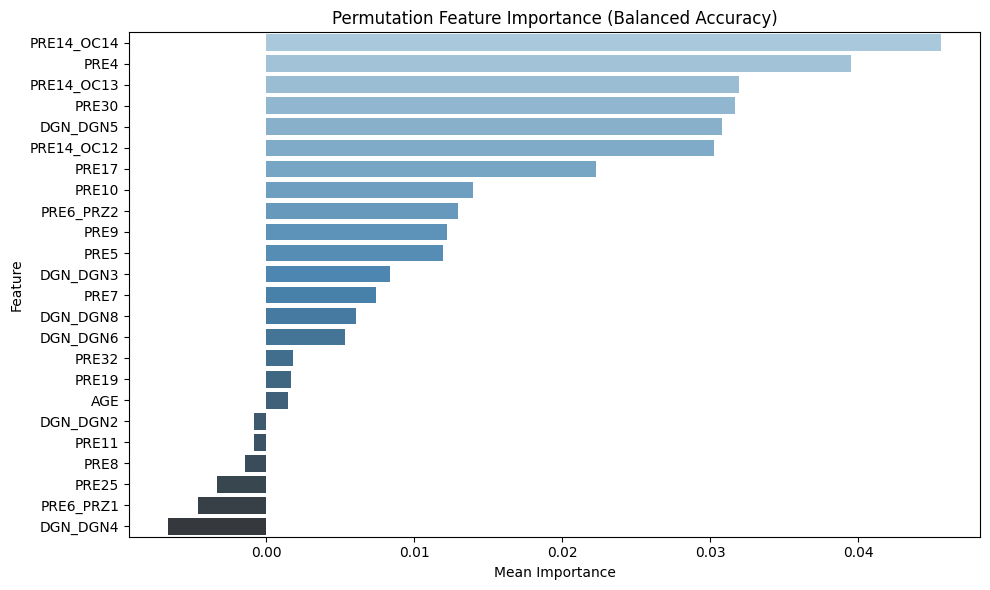

In [35]:

###  Permutation Importance on the trained model
result = permutation_importance(full_pipeline, X, y, n_repeats=10, random_state=1, scoring='balanced_accuracy')

# Convert to DataFrame
importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance Mean': result.importances_mean,
    'Importance Std': result.importances_std
}).sort_values(by='Importance Mean', ascending=False)

# Plot permutation importances
plt.figure(figsize=(10, 6))
sns.barplot(data=importances_df, x='Importance Mean', y='Feature', palette='Blues_d')
plt.title('Permutation Feature Importance (Balanced Accuracy)')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### **Identify least important features**

In [36]:

###  Identify least important features
least_important_features = importances_df.tail(2)['Feature'].tolist()
F1, F2 = least_important_features[0], least_important_features[1]

### Custom transformer to drop columns
class FeatureDropper(BaseEstimator, TransformerMixin):
    def __init__(self, features_to_drop):
        self.features_to_drop = features_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.features_to_drop)


In [37]:

### Evaluate model with feature ablations
def ablation_test(features_to_remove, label):
    pipeline = ImbPipeline([
        ('dropper', FeatureDropper(features_to_remove)),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=1)),
        ('clf', final_model)
    ])

    scores = cross_validate(
        pipeline, X, y, cv=outer_cv,
        scoring={
            'accuracy': 'accuracy',
            'balanced_accuracy': 'balanced_accuracy',
            'f1': 'f1'
        },
        return_train_score=True,
        n_jobs=-1
    )

    print(f"\n--- Results with {label} ---")
    for metric in ['accuracy', 'balanced_accuracy', 'f1']:
        print(f"{metric.upper()} - Train: {np.mean(scores[f'train_{metric}']):.3f}, Test: {np.mean(scores[f'test_{metric}']):.3f}")


In [38]:

# Original model (no features removed)
ablation_test([], "All Features")



--- Results with All Features ---
ACCURACY - Train: 0.658, Test: 0.615
BALANCED_ACCURACY - Train: 0.708, Test: 0.621
F1 - Train: 0.405, Test: 0.326


In [39]:

# Remove F1 only
ablation_test([F1], f"Without {F1}")



--- Results with Without PRE6_PRZ1 ---
ACCURACY - Train: 0.663, Test: 0.626
BALANCED_ACCURACY - Train: 0.711, Test: 0.627
F1 - Train: 0.409, Test: 0.334


In [40]:

# Remove F2 only
ablation_test([F2], f"Without {F2}")



--- Results with Without DGN_DGN4 ---
ACCURACY - Train: 0.660, Test: 0.630
BALANCED_ACCURACY - Train: 0.710, Test: 0.637
F1 - Train: 0.407, Test: 0.343


In [41]:

# Remove both F1 and F2
ablation_test([F1, F2], f"Without {F1} and {F2}")



--- Results with Without PRE6_PRZ1 and DGN_DGN4 ---
ACCURACY - Train: 0.666, Test: 0.630
BALANCED_ACCURACY - Train: 0.714, Test: 0.629
F1 - Train: 0.412, Test: 0.337



#### Results Summary:

| Feature Set                 | Accuracy (Test) | Balanced Accuracy (Test) | F1 Score (Test) |
|----------------------------|-----------------|---------------------------|-----------------|
| All Features               | 0.615           | 0.621                     | 0.326           |
| Without `PRE6_PRZ1`        | 0.626           | 0.627                     | 0.334           |
| Without `DGN_DGN4`         | 0.630           | 0.637                     | 0.343           |
| Without Both (`F1`, `F2`)  | **0.630**       | **0.629**                 | 0.337           |

#### Interpretation:

- Removing either of the least important features led to **slight improvements** in all three metrics, particularly **F1 score**.
- Removing both features maintained or improved test scores while not harming training performance.
- This supports the **reliability of the permutation importance** results and suggests that `PRE6_PRZ1` and `DGN_DGN4` may introduce noise or redundancy into the model.
- The final model appears to **benefit from reduced feature complexity**, improving generalization without further tuning.

####  Conclusion:
This ablation study not only confirmed the results from permutation importance, but also demonstrated that removing less relevant features can **slightly boost performance** and simplify the model without loss in predictive power.




## Task 8 – Conclusions and Future Work

### Summary and Interpretation of Results

Over the course of this study, multiple machine learning models were evaluated to classify patient survival one year after thoracic surgery.
Key findings include:

* **Baseline Model** (most frequent class): Failed to capture any patterns (F1 = 0.00, BA = 0.50).
* **Decision Tree**: Overfit the training data (Train F1 = 0.60+) but failed to generalize (Test F1 ≈ 0.23).
* **Support Vector Classifier (SVC)**: After hyperparameter tuning via nested cross-validation, it achieved the **best overall test performance** (Test F1 ≈ 0.32, Test BA ≈ 0.62), showing good balance between precision and recall under class imbalance.

The **feature importance and ablation study** also showed that removing uninformative features slightly improved or preserved performance, suggesting the final model is **robust and not overly dependent on noisy predictors**.



### Value Generated in Context

This project provides a **proof of concept** that machine learning models, particularly SVMs, can support decision-making in medical prognosis following surgery. While predictive accuracy is modest, it:

* Demonstrates feasibility of applying ML to small, imbalanced clinical datasets,
* Identifies influential features (e.g., preoperative conditions, diagnostic categories),
* Highlights the critical need for more representative and larger datasets to improve reliability.



### Specific Ideas for Future Work


**Explore survival analysis models**  instead of binary classification, as they inherently model time-to-event data and may better reflect real-world survival variability.

### Critical Reflection

#### What worked well:

* The use of **nested cross-validation** provided robust performance estimates and avoided data leakage during tuning.
* Combining **SMOTE** with pipeline-based modeling ensured fairness in learning from the minority class.

#### Limitations:

* The dataset is **small and highly imbalanced**, making generalization difficult.
* Binary classification may oversimplify the **complex trajectory of post-operative recovery**.

#### Improvements:

* A **larger and richer dataset** should be sought before model selection.



### Final Reflection

The goals were **ambitious yet realistic** for a first ML-driven medical data study. Despite data constraints, the workflow demonstrated how modern ML techniques can be responsibly and transparently applied to sensitive health data. With targeted improvements, this work can serve as a strong foundation for future clinical prediction models.
